# Financial Sentiment Analysis
## STAGE 1 — Local NLP Prototype

In [2]:
import pandas as pd

df = pd.read_csv("data.csv")

In [3]:
df.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [4]:
df["Sentiment"].value_counts()

Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64

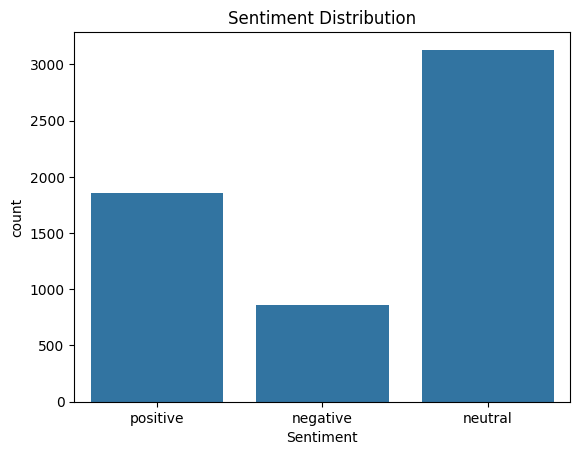

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="Sentiment",
    data=df
)

plt.title("Sentiment Distribution")
plt.show()

In [6]:
df.isnull().sum()

Sentence     0
Sentiment    0
dtype: int64

In [7]:
df.sample(5)

,Sentence,Sentiment
5338,"In addition to the Tulikivi Corporation , he i...",neutral
170,The amending of the proposal simplifies the pr...,positive
630,Tesco sales recover as focus returns to core b...,positive
2235,11 August 2010 - Finnish measuring equipment m...,negative
521,"DBS, Julius Baer emerge as potential bidders f...",positive


In [8]:
# Sentence length analysis for the `Sentence` column
sentence_lengths = df["Sentence"].astype(str).str.split().str.len()

print("max length:", sentence_lengths.max())
print("min length:", sentence_lengths.min())
print("avg length:", int(sentence_lengths.mean()))

# Optional: inspect the rows with the longest and shortest sentences
print("\nLongest sentence row:")
print(df.loc[sentence_lengths.idxmax(), ["Sentence"]])
print("\nShortest sentence row:")
print(df.loc[sentence_lengths.idxmin(), ["Sentence"]])

max length: 81
min length: 2
avg length: 21

Longest sentence row:
Sentence    Supported Nokia phones include : N96 , N95-8GB...
Name: 3800, dtype: object

Shortest sentence row:
Sentence    $TSLA recall
Name: 98, dtype: object


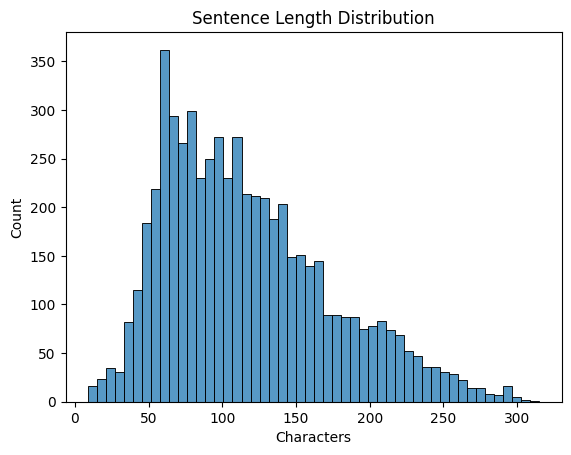

In [9]:
df["length"] = df["Sentence"].apply(len)

sns.histplot(df["length"], bins=50)

plt.title("Sentence Length Distribution")
plt.xlabel("Characters")
plt.show()

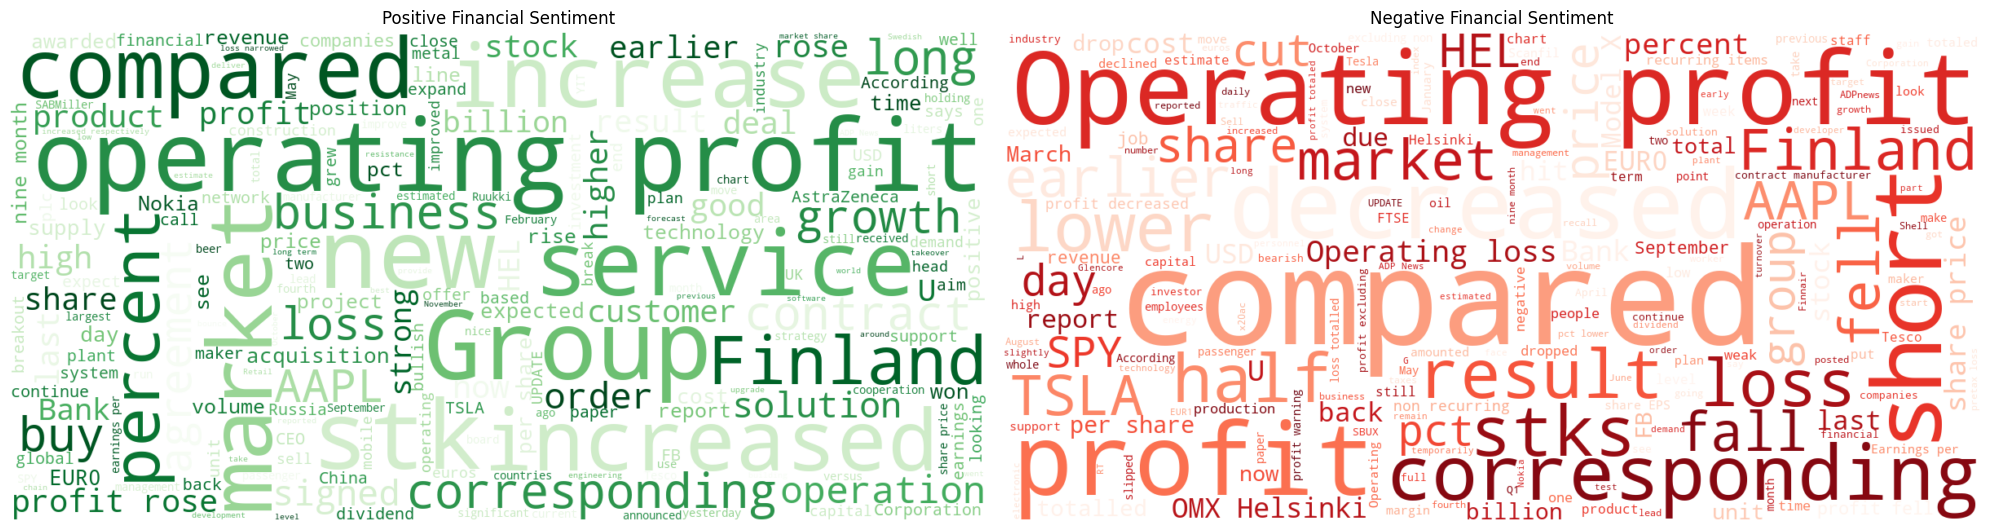

In [11]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Stopwords
from wordcloud import STOPWORDS

stopwords = set(STOPWORDS)

stopwords.update([
    "company",
    "said",
    "will",
    "million",
    "mln",
    "eur",
    "euro",
    "year",
    "years",
    "today",
    "first",
    "second",
    "third",
    "quarter",
    "period",
    "finnish",
    "https",
    "http",
    "www",
    "com",
    "t",
    "co",
    "oyj",
    "net", 
    "mn", 
    "s", "m", 
    "sale", 
    "sales"
])

# Positive text
positive_text = " ".join(
    df[df["Sentiment"] == "positive"]["Sentence"]
)

# Negative text
negative_text = " ".join(
    df[df["Sentiment"] == "negative"]["Sentence"]
)

# Positive word cloud
positive_wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stopwords,
    colormap="Greens"
).generate(positive_text)

# Negative word cloud
negative_wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stopwords,
    colormap="Reds"
).generate(negative_text)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Positive
axes[0].imshow(positive_wc, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Positive Financial Sentiment")

# Negative
axes[1].imshow(negative_wc, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Negative Financial Sentiment")

plt.tight_layout()

plt.show()

In [46]:
df = df.dropna() 
df["Sentence"] = ( df["Sentence"] .astype(str) .str.strip() ) 
df["Sentence"] = df["Sentence"].apply( lambda x: x[0].upper() + x[1:] if len(x) > 0 else x )

In [ ]:
label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["label"] = df["Sentiment"].map(label_map)

In [12]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", LogisticRegression())
])

pipeline.fit(
    train_df["Sentence"],
    train_df["label"]
)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('model', LogisticRegression())])

In [14]:
preds = pipeline.predict(test_df["Sentence"])

## Naive Bayes


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", MultinomialNB())
])

nb_pipeline.fit(
    train_df["Sentence"],
    train_df["label"]
)

nb_preds = nb_pipeline.predict(
    test_df["Sentence"]
)

print(classification_report(
    test_df["label"],
    nb_preds
))

              precision    recall  f1-score   support

           0       1.00      0.02      0.05       172
           1       0.64      0.99      0.77       626
           2       0.76      0.40      0.52       371

    accuracy                           0.66      1169
   macro avg       0.80      0.47      0.45      1169
weighted avg       0.73      0.66      0.59      1169



## Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(
    train_df["Sentence"],
    train_df["label"]
)

lr_preds = lr_pipeline.predict(
    test_df["Sentence"]
)

print(classification_report(
    test_df["label"],
    lr_preds
))

              precision    recall  f1-score   support

           0       0.31      0.13      0.18       172
           1       0.71      0.88      0.79       626
           2       0.76      0.66      0.71       371

    accuracy                           0.70      1169
   macro avg       0.59      0.56      0.56      1169
weighted avg       0.67      0.70      0.67      1169



## SVM 

In [17]:
from sklearn.svm import LinearSVC

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", LinearSVC())
])

svm_pipeline.fit(
    train_df["Sentence"],
    train_df["label"]
)

svm_preds = svm_pipeline.predict(
    test_df["Sentence"]
)

print(classification_report(
    test_df["label"],
    svm_preds
))

              precision    recall  f1-score   support

           0       0.26      0.19      0.22       172
           1       0.72      0.80      0.76       626
           2       0.78      0.75      0.76       371

    accuracy                           0.69      1169
   macro avg       0.59      0.58      0.58      1169
weighted avg       0.67      0.69      0.68      1169



## DistilBERT

In [18]:
from transformers import pipeline
from sklearn.metrics import classification_report

distilbert_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

distilbert_preds = []

for text in test_df["Sentence"]:
    
    result = distilbert_model(text[:512])[0]["label"]

    if result == "POSITIVE":
        distilbert_preds.append(2)
    else:
        distilbert_preds.append(0)

print(classification_report(
    test_df["label"],
    distilbert_preds
))

/Users/roma/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Device set to use mps:0


              precision    recall  f1-score   support

           0       0.22      0.95      0.36       172
           1       0.00      0.00      0.00       626
           2       0.40      0.48      0.44       371

    accuracy                           0.29      1169
   macro avg       0.21      0.47      0.27      1169
weighted avg       0.16      0.29      0.19      1169



/Users/roma/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/roma/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/roma/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## FinBERT

In [19]:
from transformers import pipeline
finbert_model = pipeline(
    "text-classification",
    model="ProsusAI/finbert"
)

finbert_preds = []

for text in test_df["Sentence"]:

    result = finbert_model(text[:512])[0]["label"]

    if result == "positive":
        finbert_preds.append(2)

    elif result == "neutral":
        finbert_preds.append(1)

    else:
        finbert_preds.append(0)

print(classification_report(
    test_df["label"],
    finbert_preds
))


Device set to use mps:0


              precision    recall  f1-score   support

           0       0.48      0.79      0.60       172
           1       0.82      0.75      0.78       626
           2       0.86      0.73      0.79       371

    accuracy                           0.75      1169
   macro avg       0.72      0.76      0.72      1169
weighted avg       0.78      0.75      0.76      1169



In [ ]:
from sklearn.metrics import accuracy_score

results = {
    "Naive Bayes": accuracy_score(test_df["label"], nb_preds),
    "Logistic Regression": accuracy_score(test_df["label"], lr_preds),
    "SVM": accuracy_score(test_df["label"], svm_preds),
    "DistilBERT": accuracy_score(test_df["label"], distilbert_preds),
    "FinBERT": accuracy_score(test_df["label"], finbert_preds)
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")


Naive Bayes: 0.6578
Logistic Regression: 0.6997
SVM: 0.6912
DistilBERT: 0.2908
FinBERT: 0.7494


,Model,Accuracy
0,Naive Bayes,0.6578
1,Logistic Regression,0.6997
2,SVM,0.6912
3,DistilBERT,0.2908
4,FinBERT,0.7494


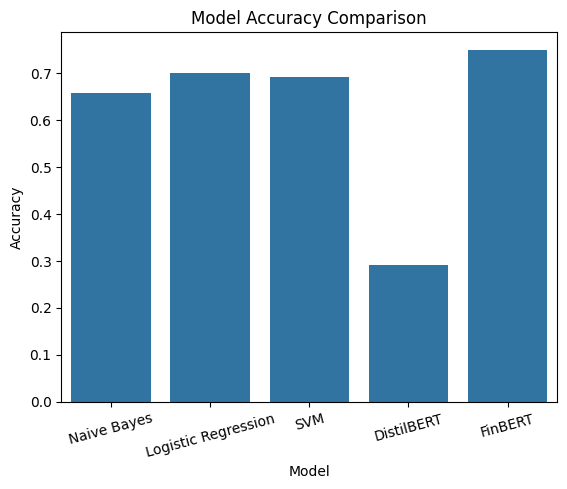

In [ ]:
comparison_df = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "SVM",
        "DistilBERT",
        "FinBERT"
    ],
    
    "Accuracy": [
        0.6578,
        0.6997,
        0.6912,
        0.2908,
        0.7494
    ]
})

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=15)

plt.title("Model Accuracy Comparison")

plt.show()

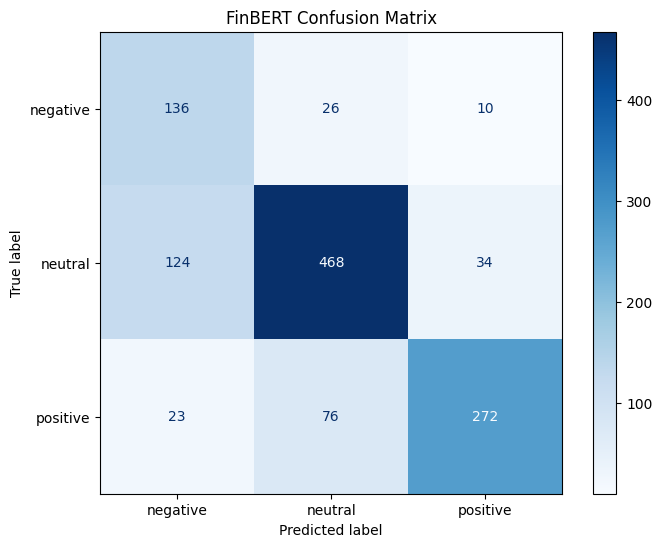

In [32]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(
    test_df["label"],
    finbert_preds
)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "neutral", "positive"]
)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(
    cmap="Blues",
    ax=ax
)

plt.title("FinBERT Confusion Matrix")

plt.show()

In [33]:
results = test_df.copy()

results["prediction"] = finbert_preds

In [38]:
wrong_preds = results[
    results["label"] != results["prediction"]
]

label_names = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

wrong_preds["real_label"] = wrong_preds["label"].map(label_names)

wrong_preds["predicted_label"] = wrong_preds["prediction"].map(label_names)
wrong_preds[
    ["Sentence", "real_label", "predicted_label"]
].head(20)

/var/folders/bf/gbtpq57x2t93j7v5vpn8t3yc0000gn/T/ipykernel_87442/1751827404.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wrong_preds["real_label"] = wrong_preds["label"].map(label_names)
/var/folders/bf/gbtpq57x2t93j7v5vpn8t3yc0000gn/T/ipykernel_87442/1751827404.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wrong_preds["predicted_label"] = wrong_preds["prediction"].map(label_names)


,Sentence,real_label,predicted_label
1399,$RAD All my charts are flashing oversold.,neutral,negative
1942,Operating loss landed at EUR39m including one-...,neutral,negative
4853,$YHOO making new HOD,positive,neutral
4410,$KITD Looking for a oversold bounce.,positive,negative
2772,$NFLX I say it's time to short at this point.,negative,neutral
4266,"Tesco set to sell Kipa, Giraffe businesses - S...",negative,neutral
4315,FDA Approves AstraZeneca's Iressa As Lung Canc...,positive,neutral
4214,The other actions include the cutting of the e...,neutral,negative
5448,Finnish media group Talentum has issued a prof...,neutral,negative
5657,"CEOs of BPM, UBI meet Italy econ minister as M...",positive,neutral


In [39]:
wrong_preds.groupby(
    ["real_label", "predicted_label"]
).size()

real_label  predicted_label
negative    neutral             26
            positive            10
neutral     negative           124
            positive            34
positive    negative            23
            neutral             76
dtype: int64

In [45]:
text = "ING reports strong quarterly profits"

result = finbert_model(text)

print(result)

[{'label': 'positive', 'score': 0.6526481509208679}]
